# 03. 데이터 분할 및 EDA (STEP 5 → 탐색적 데이터 분석)

`02_preprocessing.ipynb`에서 파생변수 28개까지 생성했습니다.
이 노트북은 **분할을 먼저 수행한 뒤, train set만으로 EDA**를 진행합니다.

---

## 왜 EDA보다 분할이 먼저인가

일반적인 순서는 EDA → 전처리 → 분할입니다. 여기서는 분할을 앞에 둡니다.

EDA의 결론은 그 자체로 끝나지 않고 **변수 선택의 근거**가 됩니다.
전체 데이터로 EDA를 하면 test set에 들어갈 행의 정보가 그 판단에 반영되고,
이후 같은 test로 성능을 측정하면 **답을 보고 고른 변수로 채점받는 구조**가 됩니다.

이를 선택 편향에 의한 데이터 누수(selection leakage)라고 합니다.
성능 지표가 실제 일반화 성능보다 낙관적으로 나오지만, 값만 봐서는 탐지할 수 없습니다.

`02_preprocessing.ipynb` STEP 1에서 정리한 원칙과 동일한 논리입니다.

> 판단 근거가 데이터 분포에 의존하는 작업은 분할 이후에 수행한다.

## 이 노트북의 구성

| 단계 | 내용 |
|---|---|
| **STEP 5** | train / test 분할 |
| **EDA 1** | 기초 통계 |
| **EDA 2** | Target 분포 |
| **EDA 3** | Feature 분포와 왜도 |
| **EDA 4** | Feature ↔ Target 관계 (선형·비선형) |
| **EDA 5** | 상관관계와 다중공선성(VIF) |
| **EDA 6** | 공정성 점검 — 모델에서 제외한 인구통계 변수 |
| **EDA 7** | prompt 편중 점검 |
| **정리** | 확인 사항 5문항에 대한 답변 |

## 산출물

- `data/train.csv`, `data/test.csv`
- `data/eda_feature_report.csv` — 변수별 통계·상관·VIF 종합표

In [2]:
# ── 라이브러리 및 전역 설정 ────────────────────────────────

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'NanumBarunGothic', 'Noto Sans CJK KR']:
    if _f in _avail:
        plt.rc('font', family=_f)
        plt.rcParams['axes.unicode_minus'] = False
        print(f'그래프 한글 폰트: {_f}')
        break
else:
    print('한글 폰트 미발견 — 그래프 제목의 한글이 깨질 수 있습니다.')

# 분할 결과를 재현하기 위한 난수 시드.
# 이 값을 고정하지 않으면 실행할 때마다 다른 분할이 나와
# 성능 비교가 불가능해집니다.
SEED = 42
TARGET = 'Vocabulary'

df = pd.read_csv('data/processed_features.csv')
print(f'불러온 데이터: {df.shape[0]}행 × {df.shape[1]}열')

그래프 한글 폰트: Malgun Gothic
불러온 데이터: 3747행 × 41열


---

# STEP 5. train / test 분할

## 목적
모델 학습에 사용할 데이터와, 성능 측정에만 사용할 데이터를 분리합니다.

## 층화 추출(stratify)이 필요한 이유

무작위 분할은 각 점수 구간이 양쪽에 고르게 들어간다고 보장하지 않습니다.
특히 **관측 수가 적은 구간에서 문제가 발생**합니다.

이 데이터의 `Vocabulary` 최저 구간은 관측이 극히 적습니다.
무작위로 나누면 해당 구간이 한쪽에 몰릴 수 있고, 그러면

- train에 몰린 경우 → test에 없는 구간을 학습하게 되어 평가에 반영되지 않음
- test에 몰린 경우 → 학습한 적 없는 구간을 평가받게 되어 성능이 부당하게 낮게 측정됨

두 경우 모두 성능 지표가 실제 능력을 반영하지 못합니다.

**층화 추출**은 지정한 변수의 구성 비율을 train과 test에서 동일하게 유지합니다.
`Vocabulary`는 0.5 단위 이산형이므로 그대로 층화 기준으로 사용할 수 있습니다.

> **주의**: `stratify`는 각 범주에 최소 2개 이상의 관측을 요구합니다.
> 아래 셀에서 이 조건을 먼저 확인하고, 충족하지 못하면 희소 구간을 병합합니다.

In [3]:
# ── [5-1] 층화 가능 여부 확인 ──────────────────────────────
#
# 분할을 실행하기 전에 층화 기준이 성립하는지 검사합니다.
# 조건을 확인하지 않고 실행하면 sklearn이 예외를 발생시키며 중단됩니다.

vc = df[TARGET].value_counts().sort_index()

print(f'{TARGET} 분포')
for score, n in vc.items():
    bar = '█' * int(n / 20)
    print(f'  {score:>4}점: {n:5d}건 ({n / len(df) * 100:5.2f}%) {bar}')

print(f'\n최소 관측 구간: {vc.idxmin()}점 ({vc.min()}건)')

# 층화 추출은 각 범주에 최소 2개가 필요합니다.
STRATIFY_OK = vc.min() >= 2
print(f'층화 추출 가능 여부: {STRATIFY_OK}')

# test_size 0.2 기준으로 각 구간이 test에 몇 건 들어갈지 추정합니다.
print('\ntest set 예상 배정 건수 (test_size=0.2)')
for score, n in vc.items():
    est = n * 0.2
    warn = '  ← 1건 미만' if est < 1 else ''
    print(f'  {score:>4}점: {est:5.1f}건{warn}')

Vocabulary 분포
   1.0점:     2건 ( 0.05%) 
   1.5점:    12건 ( 0.32%) 
   2.0점:   122건 ( 3.26%) ██████
   2.5점:   515건 (13.74%) █████████████████████████
   3.0점:  1443건 (38.51%) ████████████████████████████████████████████████████████████████████████
   3.5점:   965건 (25.75%) ████████████████████████████████████████████████
   4.0점:   548건 (14.63%) ███████████████████████████
   4.5점:   105건 ( 2.80%) █████
   5.0점:    35건 ( 0.93%) █

최소 관측 구간: 1.0점 (2건)
층화 추출 가능 여부: True

test set 예상 배정 건수 (test_size=0.2)
   1.0점:   0.4건  ← 1건 미만
   1.5점:   2.4건
   2.0점:  24.4건
   2.5점: 103.0건
   3.0점: 288.6건
   3.5점: 193.0건
   4.0점: 109.6건
   4.5점:  21.0건
   5.0점:   7.0건


In [4]:
# ── [5-2] 분할 실행 ────────────────────────────────────────
#
# test_size=0.2는 관례적인 값입니다.
# 3,747행에서 test 약 750행이면 성능 지표를 안정적으로 추정할 수 있는 규모입니다.
#
# 층화 기준으로 Vocabulary를 그대로 사용합니다.
# 연속형 타겟이라면 구간화(binning)가 필요하지만,
# 이 타겟은 0.5 단위 이산형이라 범주처럼 다룰 수 있습니다.

TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df[TARGET] if STRATIFY_OK else None,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'train: {train_df.shape[0]}행 ({train_df.shape[0] / len(df) * 100:.1f}%)')
print(f'test : {test_df.shape[0]}행 ({test_df.shape[0] / len(df) * 100:.1f}%)')

# 분할이 의도대로 되었는지 검증합니다.
# 실행했다는 사실이 아니라 결과가 조건을 만족하는지 확인하는 것이 목적입니다.
cmp = pd.DataFrame({
    'train_건수': train_df[TARGET].value_counts().sort_index(),
    'test_건수': test_df[TARGET].value_counts().sort_index(),
})
cmp['train_비율(%)'] = (cmp['train_건수'] / len(train_df) * 100).round(2)
cmp['test_비율(%)'] = (cmp['test_건수'] / len(test_df) * 100).round(2)
cmp['비율차'] = (cmp['train_비율(%)'] - cmp['test_비율(%)']).round(2)

print('\n분할 후 Target 분포 비교')
print(cmp.fillna(0).to_string())
print(f'\n최대 비율차: {cmp["비율차"].abs().max():.2f}%p')
print('  → 0에 가까울수록 두 집합의 분포가 동일합니다.')

train_df.to_csv('data/train.csv', index=False)
test_df.to_csv('data/test.csv', index=False)
print('\n저장 완료: data/train.csv, data/test.csv')

train: 2997행 (80.0%)
test : 750행 (20.0%)

분할 후 Target 분포 비교
            train_건수  test_건수  train_비율(%)  test_비율(%)   비율차
Vocabulary                                                  
1.0                2      0.0         0.07        0.00  0.00
1.5               10      2.0         0.33        0.27  0.06
2.0               97     25.0         3.24        3.33 -0.09
2.5              412    103.0        13.75       13.73  0.02
3.0             1154    289.0        38.51       38.53 -0.02
3.5              772    193.0        25.76       25.73  0.03
4.0              438    110.0        14.61       14.67 -0.06
4.5               84     21.0         2.80        2.80  0.00
5.0               28      7.0         0.93        0.93  0.00

최대 비율차: 0.09%p
  → 0에 가까울수록 두 집합의 분포가 동일합니다.

저장 완료: data/train.csv, data/test.csv


In [5]:
# ── [5-3] 이후 분석 대상 고정 ──────────────────────────────
#
# 이 셀 이후의 모든 분석은 train만 사용합니다.
# test는 최종 성능 측정 시점까지 열지 않습니다.
#
# 변수를 명시적으로 분리해 두면 실수로 test를 참조하는 것을 방지할 수 있습니다.

eda = train_df.copy()

# 분석에 사용할 수치형 변수 목록.
# full_text, prompt, prompt_grouped는 문자열이므로 제외합니다.
NUM_COLS = [c for c in eda.columns
            if eda[c].dtype.kind in 'if' and c != TARGET]

# 02 노트북에서 정의한 변수군 구조를 유지합니다.
GROUPS = {
    'A. 다양성': ['ttr_ratio', 'guiraud', 'herdan_c', 'MTLD_valid'],
    'B. 수준': ['k1_ratio', 'k2_ratio', 'beyond_2k_ratio', 'mean_word_length',
              'mean_syllables', 'long_word_ratio', 'academic_suffix_ratio'],
    'C. 밀도': ['lexical_density', 'content_ttr', 'function_word_ratio'],
    'D. 정확성': ['oov_ratio', 'repeat_bigram_ratio', 'hapax_ratio'],
    'E. 구문': ['mean_sent_length', 'mean_para_length', 'sent_per_para',
              'sent_length_std', 'sent_length_max'],
    'F. 상대화': ['prompt_freq', 'len_z_in_prompt', 'soph_z_in_prompt'],
    'G. 플래그': ['flag_very_short', 'flag_len_outlier', 'n_pii'],
    'H. 원본': ['num_words', 'num_words3', 'num_sent', 'num_para',
              'num_word_div_para', 'MTLD', 'TTR', 'Type', 'Token'],
}
GROUP_OF = {c: g for g, cols in GROUPS.items() for c in cols}

print(f'EDA 대상: train {len(eda)}행')
print(f'수치형 변수: {len(NUM_COLS)}개')
print(f'변수군: {len(GROUPS)}개')

EDA 대상: train 2997행
수치형 변수: 37개
변수군: 8개


---

# EDA 1. 기초 통계

## 목적
각 변수가 어떤 범위와 분포를 갖는지 파악합니다.

## 여기서 보는 것

기술통계표는 숫자를 나열하는 데 의미가 있는 것이 아니라,
**모델링을 방해할 요소를 미리 찾아내는 데** 목적이 있습니다.

| 확인 항목 | 문제가 되는 경우 |
|---|---|
| 표준편차 | 0에 가까우면 변별력이 없음 |
| 최솟값·최댓값 | 정의상 불가능한 값이 있으면 계산 오류 |
| 최댓값 / 중앙값 비율 | 지나치게 크면 극단값 존재 |
| 변동계수(CV) | 평균 대비 산포. 스케일이 다른 변수 간 비교에 사용 |

In [6]:
# ── [1-1] 기술통계 및 이상 신호 탐지 ──────────────────────
#
# describe()를 그대로 출력하면 변수가 37개라 읽기 어렵습니다.
# 판단에 필요한 지표만 계산해 정렬합니다.

desc = pd.DataFrame({
    'mean': eda[NUM_COLS].mean(),
    'std': eda[NUM_COLS].std(),
    'min': eda[NUM_COLS].min(),
    'median': eda[NUM_COLS].median(),
    'max': eda[NUM_COLS].max(),
})
# 변동계수: 표준편차 / 평균. 평균이 0에 가까우면 계산이 불안정하므로 방어합니다.
desc['CV'] = (desc['std'] / desc['mean'].abs().replace(0, np.nan)).round(3)
# 최댓값이 중앙값의 몇 배인지 — 극단값 탐지용
desc['max/med'] = (desc['max'] / desc['median'].replace(0, np.nan)).round(1)
desc['변수군'] = [GROUP_OF.get(c, '-') for c in desc.index]

print('기초 통계 (train 기준)')
print(desc.round(4).to_string())

print('\n' + '=' * 70)
print('점검 결과')
print('=' * 70)

zero_var = desc[desc['std'] < 1e-8].index.tolist()
print(f'분산 0 변수: {zero_var if zero_var else "없음"}')

extreme = desc[desc['max/med'] > 10].index.tolist()
print(f'최댓값이 중앙값의 10배 초과: {extreme if extreme else "없음"}')
print('  → 극단값이 존재한다는 신호이며, 뒤의 왜도 점검과 함께 해석합니다.')

기초 통계 (train 기준)
                           mean       std      min    median        max       CV  max/med     변수군
num_words              432.1351  222.5912  47.0000  390.0000  2199.0000    0.515      5.6   H. 원본
num_words3             426.5709  186.3165  48.0000  400.0000  1260.0000    0.437      3.2   H. 원본
num_sent                18.0621   10.0950   1.0000   17.0000    90.0000    0.559      5.3   H. 원본
num_para                 5.5259    3.0251   1.0000    5.0000    44.0000    0.547      8.8   H. 원본
num_word_div_para       94.0595   72.3582   6.4545   80.0000  1192.0000    0.769     14.9   H. 원본
MTLD                    45.6881   10.9448  12.2500   44.4935   103.1422    0.240      2.3   H. 원본
TTR                     36.9548    8.2212  14.0083   36.2667    72.9167    0.222      2.0   H. 원본
Type                   149.6750   48.9299  24.0000  144.0000   370.0000    0.327      2.6   H. 원본
Token                  432.3427  188.9192  48.0000  405.0000  1268.0000    0.437      3.1   H. 원본
n_p

---

# EDA 2. Target 분포

## 목적
예측 대상의 분포를 확인하고, 그것이 모델 성능에 어떤 제약을 만드는지 파악합니다.

## 이 단계가 중요한 이유

회귀에서 타겟 분포는 **성능의 상한과 실패 양상을 미리 결정**합니다.

분포가 한 점에 몰려 있으면 모델은 그 값 근처만 예측해도 오차가 작게 나옵니다.
RMSE는 양호해 보이지만 실제로는 개체를 변별하지 못하는 상태이며,
이를 **평균 회귀(regression to the mean)** 현상이라고 합니다.

관측이 희소한 구간은 학습할 데이터가 부족해 예측이 체계적으로 빗나갑니다.
- 저점수 구간 → 과대예측(실제보다 높게)
- 고점수 구간 → 과소예측(실제보다 낮게)

**이 두 가지를 미리 확인해 두면, 모델링 이후 잔차 분석에서 나타날 패턴을
설명할 수 있습니다.**

In [7]:
# ── [2-1] Target 분포와 집중도 ────────────────────────────

y = eda[TARGET]

print(f'{TARGET} 기술통계 (train {len(y)}행)')
print(f'  평균   : {y.mean():.4f}')
print(f'  중앙값 : {y.median():.4f}')
print(f'  표준편차: {y.std():.4f}')
print(f'  최솟값 : {y.min()} / 최댓값: {y.max()}')
print(f'  왜도   : {y.skew():+.4f}')
print(f'  첨도   : {y.kurt():+.4f}')

vc = y.value_counts().sort_index()
cum = (vc.cumsum() / len(y) * 100).round(2)

print(f'\n구간별 분포')
print(f'{"점수":>6} {"건수":>7} {"비율(%)":>9} {"누적(%)":>9}')
for s in vc.index:
    print(f'{s:>6} {vc[s]:>7} {vc[s] / len(y) * 100:>9.2f} {cum[s]:>9.2f}')

# 중앙 3개 구간에 얼마나 몰려 있는지 확인합니다.
core = vc.nlargest(3)
print(f'\n상위 3개 구간({list(core.index)})이 전체의 '
      f'{core.sum() / len(y) * 100:.1f}%를 차지합니다.')

# 관측이 희소해 학습이 어려운 구간
SPARSE_N = 30
sparse = vc[vc < SPARSE_N]
print(f'\n관측 {SPARSE_N}건 미만 구간: {list(sparse.index)} '
      f'(합계 {sparse.sum()}건, 전체의 {sparse.sum() / len(y) * 100:.2f}%)')
print('  → 이 구간은 학습 데이터가 부족해 예측이 체계적으로 빗나갈 것으로 예상됩니다.')

Vocabulary 기술통계 (train 2997행)
  평균   : 3.2282
  중앙값 : 3.0000
  표준편차: 0.5796
  최솟값 : 1.0 / 최댓값: 5.0
  왜도   : +0.2043
  첨도   : +0.3568

구간별 분포
    점수      건수     비율(%)     누적(%)
   1.0       2      0.07      0.07
   1.5      10      0.33      0.40
   2.0      97      3.24      3.64
   2.5     412     13.75     17.38
   3.0    1154     38.51     55.89
   3.5     772     25.76     81.65
   4.0     438     14.61     96.26
   4.5      84      2.80     99.07
   5.0      28      0.93    100.00

상위 3개 구간([3.0, 3.5, 4.0])이 전체의 78.9%를 차지합니다.

관측 30건 미만 구간: [1.0, 1.5, 5.0] (합계 40건, 전체의 1.33%)
  → 이 구간은 학습 데이터가 부족해 예측이 체계적으로 빗나갈 것으로 예상됩니다.


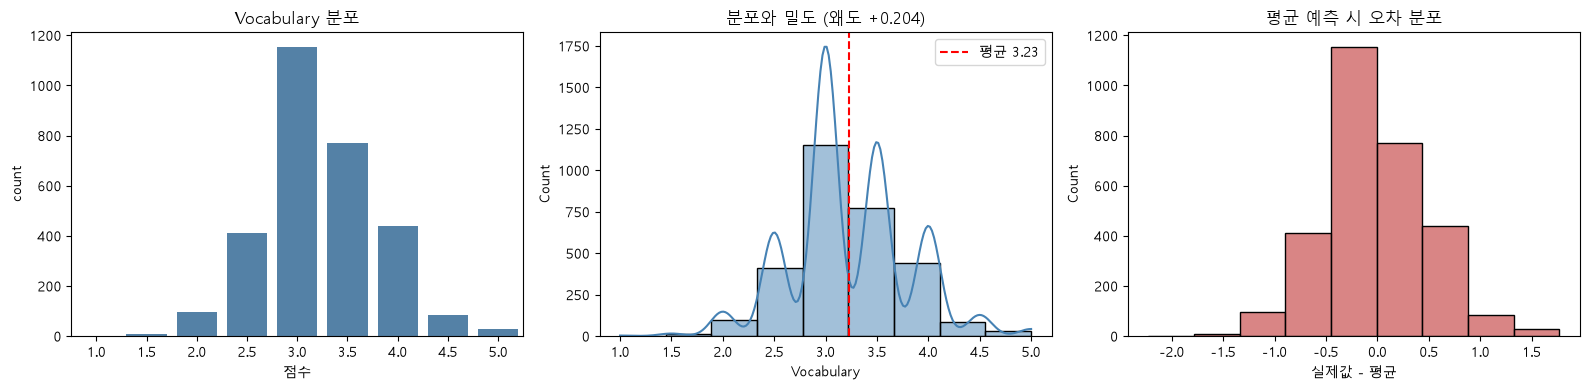

베이스라인 — 항상 평균만 예측하는 모델
  MAE  : 0.4700
  RMSE : 0.5795
  R²   : 0.0000  (정의상)

이후 만들 모든 모델은 위 수치보다 나아야 의미가 있습니다.


In [8]:
# ── [2-2] Target 분포 시각화 및 baseline 오차 ─────────────
#
# 두 번째 그림은 "아무것도 학습하지 않고 항상 평균만 예측하는 모델"의
# 오차를 보여줍니다. 이것이 모든 모델이 넘어야 할 최소 기준선입니다.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x=y, ax=axes[0], color='steelblue')
axes[0].set_title(f'{TARGET} 분포')
axes[0].set_xlabel('점수')

# 정규분포와 비교. 선형회귀는 잔차의 정규성을 가정하므로
# 타겟 분포가 얼마나 벗어나 있는지 미리 확인합니다.
sns.histplot(y, kde=True, bins=9, ax=axes[1], color='steelblue')
axes[1].axvline(y.mean(), color='red', ls='--', label=f'평균 {y.mean():.2f}')
axes[1].set_title(f'분포와 밀도 (왜도 {y.skew():+.3f})')
axes[1].legend()

# 평균 예측 모델의 오차 분포
resid_baseline = y - y.mean()
sns.histplot(resid_baseline, bins=9, ax=axes[2], color='indianred')
axes[2].set_title('평균 예측 시 오차 분포')
axes[2].set_xlabel('실제값 - 평균')

plt.tight_layout()
plt.show()

mae0 = resid_baseline.abs().mean()
rmse0 = np.sqrt((resid_baseline ** 2).mean())
print('베이스라인 — 항상 평균만 예측하는 모델')
print(f'  MAE  : {mae0:.4f}')
print(f'  RMSE : {rmse0:.4f}')
print(f'  R²   : 0.0000  (정의상)')
print('\n이후 만들 모든 모델은 위 수치보다 나아야 의미가 있습니다.')

---

# EDA 3. Feature 분포와 왜도

## 목적
각 변수의 분포 형태를 확인하고, 변환이 필요한 변수를 식별합니다.

## 왜도(skewness)를 보는 이유

선형회귀는 잔차의 정규성을 가정합니다.
설명변수 자체가 정규분포일 필요는 없지만, **심하게 치우친 변수는
소수의 극단값이 회귀계수를 지배**하게 만듭니다.

| 왜도 | 해석 |
|---|---|
| \|왜도\| < 0.5 | 대칭에 가까움 |
| 0.5 ~ 1.0 | 완만한 치우침 |
| **> 1.0** | **심한 치우침 — 로그·제곱근 변환 검토** |

비율(ratio) 변수는 0 근처에 몰리는 경우가 많아 오른쪽으로 치우치는 것이 자연스럽습니다.
변환 여부는 왜도 수치만이 아니라 **모델 종류**도 함께 고려해야 합니다.
트리 계열 모델은 분포 형태에 영향받지 않으므로 변환이 불필요합니다.

In [9]:
# ── [3-1] 왜도 점검 및 변환 후보 식별 ────────────────────

skew = pd.DataFrame({
    '왜도': eda[NUM_COLS].skew(),
    '첨도': eda[NUM_COLS].kurt(),
})
skew['변수군'] = [GROUP_OF.get(c, '-') for c in skew.index]
skew['판정'] = pd.cut(skew['왜도'].abs(),
                    bins=[-0.01, 0.5, 1.0, np.inf],
                    labels=['대칭', '완만', '심함'])
skew = skew.sort_values('왜도', key=abs, ascending=False)

print('왜도 상위 (절댓값 기준)')
print(skew.round(3).to_string())

heavy = skew[skew['왜도'].abs() > 1.0].index.tolist()
print(f'\n왜도 1.0 초과: {len(heavy)}개')
print(f'  {heavy}')
print('\n선형회귀 계열에서는 변환을 검토하고, 트리 계열에서는 그대로 사용합니다.')

왜도 상위 (절댓값 기준)
                           왜도       첨도     변수군  판정
flag_very_short        12.793  161.778  G. 플래그  심함
n_pii                  10.183  137.592  G. 플래그  심함
mean_sent_length        8.966  136.350   E. 구문  심함
sent_length_std         6.558   83.707   E. 구문  심함
flag_len_outlier        5.649   29.930  G. 플래그  심함
mean_para_length        5.597   54.883   E. 구문  심함
num_word_div_para       5.539   53.780   H. 원본  심함
sent_length_max         5.065   56.581   E. 구문  심함
sent_per_para           3.897   29.991   E. 구문  심함
oov_ratio               3.671   25.072  D. 정확성  심함
num_para                3.497   25.573   H. 원본  심함
repeat_bigram_ratio     2.979   12.562  D. 정확성  심함
beyond_2k_ratio         2.168   19.291   B. 수준  심함
num_words               2.110    8.028   H. 원본  심함
k1_ratio               -1.346    8.684   B. 수준  심함
soph_z_in_prompt        1.317    6.844  F. 상대화  심함
academic_suffix_ratio   1.204    2.036   B. 수준  심함
len_z_in_prompt         1.133    1.845  F. 상대화  심함
num_words3      

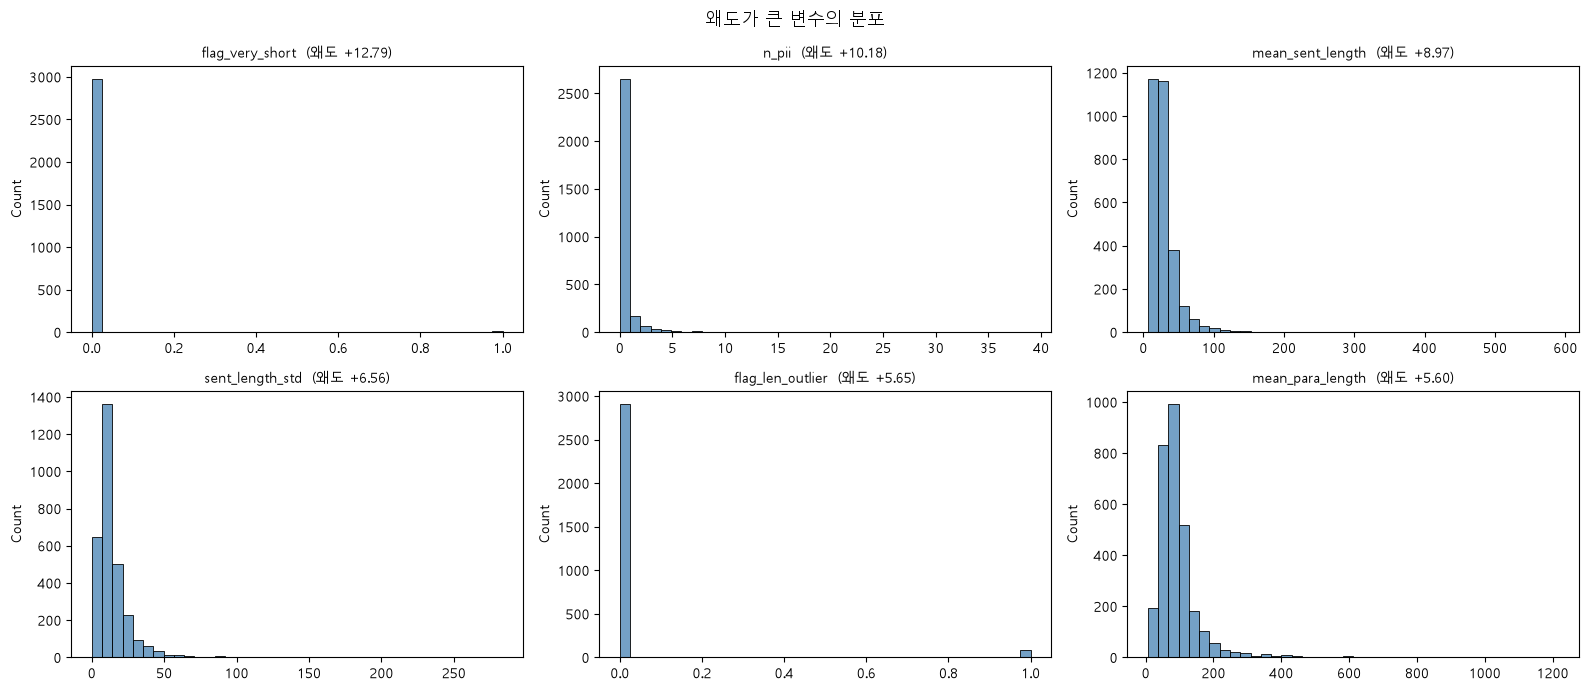

In [10]:
# ── [3-2] 치우침이 심한 변수의 분포 확인 ─────────────────
#
# 수치만으로는 치우침의 원인을 알 수 없습니다.
# 소수의 극단값 때문인지, 분포 자체가 한쪽으로 몰린 것인지 구분해야
# 대응 방법이 달라집니다.

targets = heavy[:6] if len(heavy) >= 6 else heavy

if targets:
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    for ax, col in zip(axes.ravel(), targets):
        sns.histplot(eda[col], bins=40, ax=ax, color='steelblue')
        ax.set_title(f'{col}  (왜도 {eda[col].skew():+.2f})', fontsize=10)
        ax.set_xlabel('')
    for ax in axes.ravel()[len(targets):]:
        ax.axis('off')
    fig.suptitle('왜도가 큰 변수의 분포', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('왜도 1.0 초과 변수가 없습니다.')

---

# EDA 4. Feature ↔ Target 관계

## 목적
어떤 변수가 어휘 점수와 관련되는지, 그 관계가 선형인지 확인합니다.

## 두 개의 상관계수를 함께 보는 이유

| 지표 | 의미 |
|---|---|
| **r(Target)** | 예측력. 절댓값이 클수록 좋음 |
| **r(Token)** | 길이 교란. **절댓값이 작을수록 좋음** |

r(Target)이 높아도 r(Token)이 함께 높으면, 그 변수는 어휘력이 아니라
**텍스트 길이를 재고 있을 가능성**이 있습니다.
길이는 어휘 능력의 대리변수일 뿐이며, 길이에만 의존하는 모델은
"길게 쓰면 점수가 오른다"는 잘못된 신호를 학습합니다.

## 피어슨과 스피어만을 함께 보는 이유

- **피어슨**: 직선 관계의 강도
- **스피어만**: 순위 기반. 곡선이어도 단조 증가·감소면 포착

두 값의 차이가 크면 **관계가 곡선**이라는 뜻이며,
선형회귀보다 트리 계열 모델이 유리하다는 근거가 됩니다.

In [11]:
# ── [4-1] 상관 종합표 (train 기준) ────────────────────────
#
# 02 노트북에서 계산한 상관은 전체 데이터 기준이었습니다.
# 여기서는 train만으로 다시 계산합니다. 최종 판단의 근거는 이쪽입니다.

rows = []
for c in NUM_COLS:
    pear = eda[c].corr(eda[TARGET])
    spear = eda[c].corr(eda[TARGET], method='spearman')
    rtok = eda[c].corr(eda['Token'])
    rows.append({
        '변수': c,
        '변수군': GROUP_OF.get(c, '-'),
        'r(Target)': round(pear, 3),
        'ρ(Target)': round(spear, 3),
        '차이': round(abs(spear) - abs(pear), 3),
        'r(Token)': round(rtok, 3),
    })

corr_tbl = pd.DataFrame(rows).set_index('변수')
corr_tbl = corr_tbl.sort_values('r(Target)', key=abs, ascending=False)

print('Feature ↔ Target 상관 (train 기준)')
print(corr_tbl.to_string())

print('\n' + '=' * 70)
print('길이 교란이 적으면서 예측력이 있는 변수 (권장 후보)')
print('=' * 70)
good = corr_tbl[(corr_tbl['r(Target)'].abs() >= 0.15) &
                (corr_tbl['r(Token)'].abs() <= 0.40)]
print(good.to_string() if len(good) else '  해당 없음')

print('\n' + '=' * 70)
print('예측력은 있으나 길이 교란이 큰 변수 (해석 주의)')
print('=' * 70)
risky = corr_tbl[(corr_tbl['r(Target)'].abs() >= 0.15) &
                 (corr_tbl['r(Token)'].abs() > 0.40)]
print(risky.to_string() if len(risky) else '  해당 없음')

Feature ↔ Target 상관 (train 기준)
                          변수군  r(Target)  ρ(Target)     차이  r(Token)
변수                                                                  
Type                    H. 원본      0.388      0.393  0.005     0.849
guiraud                A. 다양성      0.380      0.368 -0.013     0.364
MTLD_valid             A. 다양성      0.346      0.347  0.000     0.094
MTLD                    H. 원본      0.346      0.344 -0.001     0.071
num_sent                H. 원본      0.341      0.370  0.030     0.623
oov_ratio              D. 정확성     -0.315     -0.282 -0.033    -0.113
len_z_in_prompt        F. 상대화      0.270      0.303  0.033     0.947
Token                   H. 원본      0.266      0.296  0.030     1.000
num_words3              H. 원본      0.265      0.295  0.030     0.999
mean_syllables          B. 수준      0.234      0.221 -0.012    -0.047
mean_word_length        B. 수준      0.232      0.226 -0.007    -0.074
long_word_ratio         B. 수준      0.210      0.199 -0.011    -0.072
num

In [12]:
# ── [4-2] 비선형 관계 탐지 ────────────────────────────────
#
# 피어슨 상관은 직선 관계만 포착합니다.
# 스피어만(순위 상관)이 피어슨보다 뚜렷하게 크면 곡선 관계를 의미합니다.
#
# 이 차이는 모델 선택의 직접적 근거가 됩니다.
#   차이가 작다 → 선형회귀로 충분
#   차이가 크다 → Random Forest 등 비선형 모델이 유리

NONLIN_TH = 0.03
nonlin = corr_tbl[corr_tbl['차이'] > NONLIN_TH].sort_values('차이', ascending=False)

print(f'스피어만이 피어슨보다 {NONLIN_TH} 이상 큰 변수 (비선형 의심)')
if len(nonlin):
    print(nonlin[['변수군', 'r(Target)', 'ρ(Target)', '차이']].to_string())
else:
    print('  해당 없음 — 관계가 대체로 선형입니다.')

print('\n해석: 차이가 큰 변수가 많을수록 트리 계열 모델의 상대적 우위가 커집니다.')

스피어만이 피어슨보다 0.03 이상 큰 변수 (비선형 의심)
                      변수군  r(Target)  ρ(Target)     차이
변수                                                    
mean_para_length    E. 구문      0.071      0.195  0.124
num_word_div_para   H. 원본      0.071      0.194  0.123
sent_per_para       E. 구문      0.176      0.295  0.120
num_words           H. 원본      0.176      0.267  0.091
len_z_in_prompt    F. 상대화      0.270      0.303  0.033

해석: 차이가 큰 변수가 많을수록 트리 계열 모델의 상대적 우위가 커집니다.


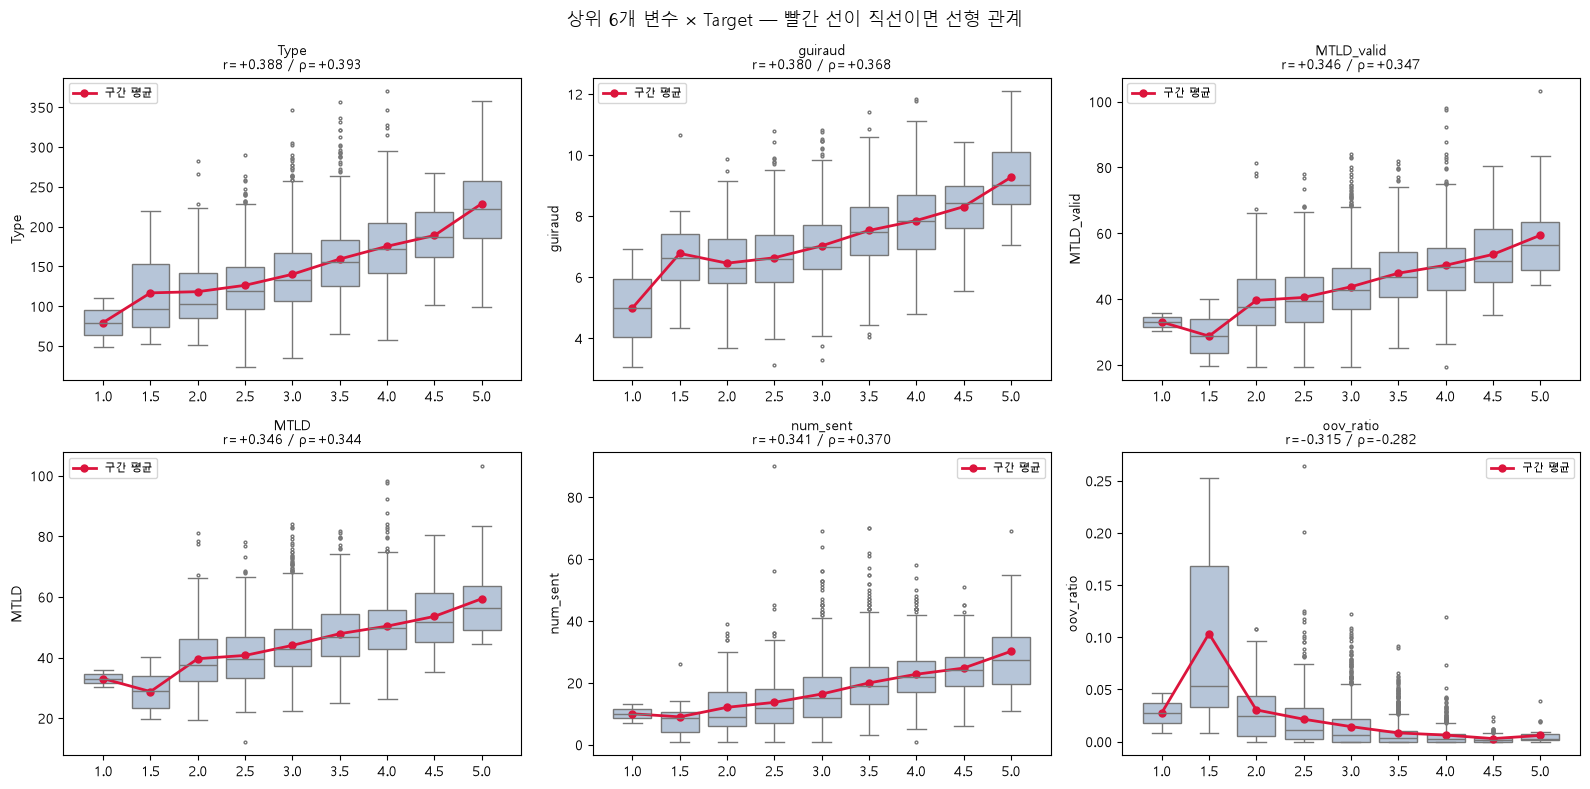

빨간 선이 휘어 있으면 비선형 관계이며, 선형회귀가 그 부분을 놓칩니다.


In [13]:
# ── [4-3] 상위 변수의 관계 형태 시각화 ────────────────────
#
# 상관계수 하나로는 관계의 '모양'을 알 수 없습니다.
# 같은 r = 0.3이라도 직선일 수도, 어느 지점부터 평평해지는 곡선일 수도 있습니다.
#
# 타겟이 이산형이므로 산점도만으로는 겹쳐 보입니다.
# 점수 구간별 평균을 함께 그려 추세를 확인합니다.

top6 = corr_tbl.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), top6):
    # 점수별 분포는 박스플롯으로
    sns.boxplot(x=eda[TARGET], y=eda[col], ax=ax,
                color='lightsteelblue', fliersize=2)
    # 구간별 평균을 선으로 겹쳐 추세를 확인
    means = eda.groupby(TARGET)[col].mean()
    ax.plot(range(len(means)), means.values, 'o-', color='crimson',
            lw=2, ms=5, label='구간 평균')
    r = corr_tbl.loc[col, 'r(Target)']
    rho = corr_tbl.loc[col, 'ρ(Target)']
    ax.set_title(f'{col}\nr={r:+.3f} / ρ={rho:+.3f}', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('상위 6개 변수 × Target — 빨간 선이 직선이면 선형 관계', fontsize=13)
plt.tight_layout()
plt.show()

print('빨간 선이 휘어 있으면 비선형 관계이며, 선형회귀가 그 부분을 놓칩니다.')

---

# EDA 5. 상관관계와 다중공선성

## 목적
변수끼리 겹치는 정보를 찾아내 STEP 6의 제거 후보를 확정합니다.

## 상관과 VIF의 차이

**상관계수는 두 변수 사이만 봅니다.**
그런데 어떤 변수는 개별 상관은 낮은데 **여러 변수의 조합으로 재현**될 수 있습니다.
예를 들어 `Token`과 `Type` 각각과는 상관이 낮아도, 두 변수의 조합으로
거의 완벽히 설명되는 변수가 존재할 수 있습니다.

**VIF(Variance Inflation Factor)** 는 이를 잡아냅니다.

> VIF_i = 1 / (1 − R²_i)
> R²_i = 변수 i를 나머지 전체 변수로 회귀했을 때의 결정계수

| VIF | 해석 |
|---|---|
| ~1 | 독립적 |
| 5 이상 | 주의 |
| **10 이상** | **심각 — 제거 검토** |
| ∞ | 완전 종속 — 반드시 제거 |

## 다중공선성이 문제인 이유

예측 성능 자체는 크게 떨어지지 않습니다. 문제는 **회귀계수의 해석**입니다.

겹치는 변수들 사이에서 계수가 불안정하게 배분되어,
같은 데이터를 조금만 바꿔도 부호가 뒤집힙니다.
"어떤 언어 특성이 어휘 점수를 설명하는가"에 답하는 것이 이 프로젝트의 목적이므로,
계수 해석이 불가능해지면 프로젝트의 핵심이 무너집니다.

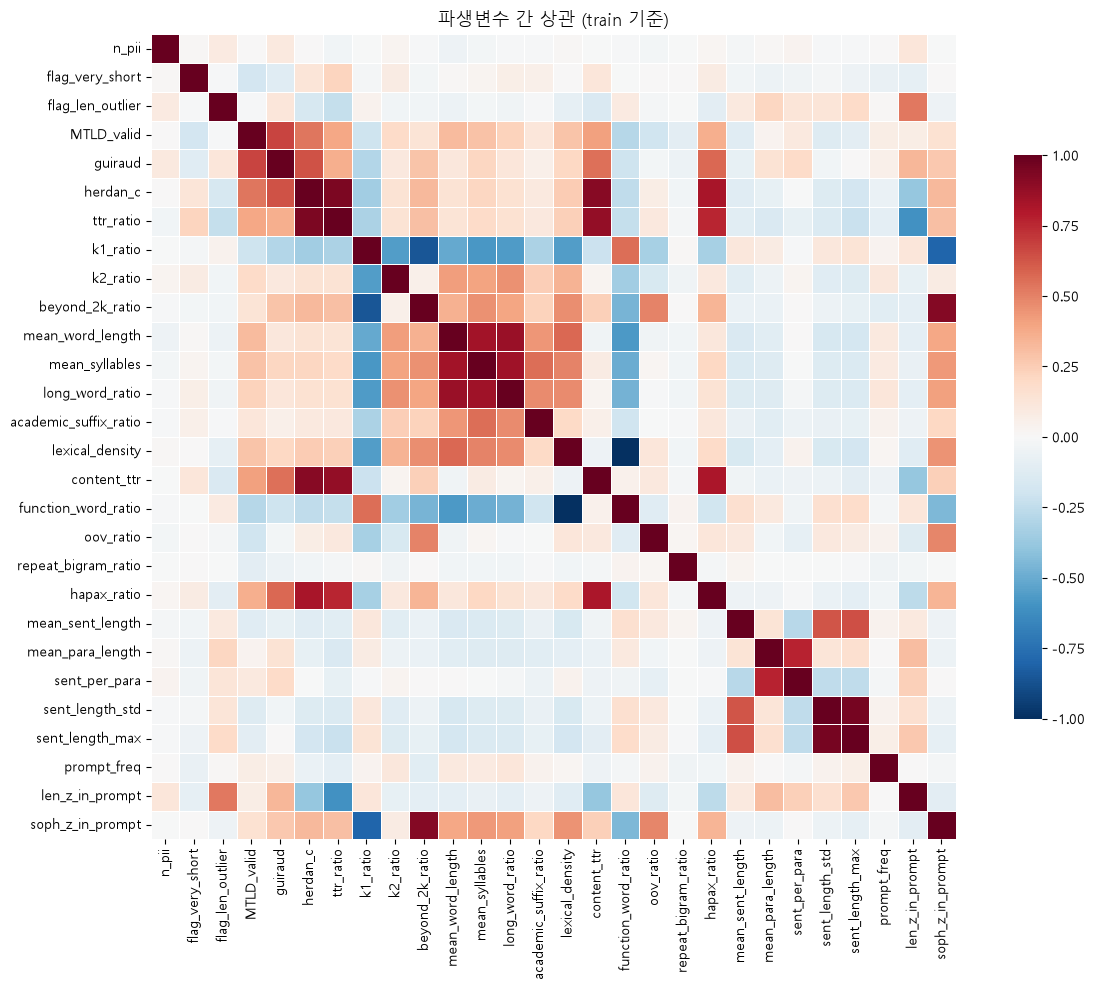

상관 0.85 초과 쌍
  lexical_density          ↔ function_word_ratio      r=1.000  → 유지 권장: lexical_density
  sent_length_std          ↔ sent_length_max          r=0.954  → 유지 권장: sent_length_std
  herdan_c                 ↔ ttr_ratio                r=0.943  → 유지 권장: herdan_c
  beyond_2k_ratio          ↔ soph_z_in_prompt         r=0.915  → 유지 권장: beyond_2k_ratio
  herdan_c                 ↔ content_ttr              r=0.909  → 유지 권장: herdan_c
  ttr_ratio                ↔ content_ttr              r=0.878  → 유지 권장: content_ttr
  mean_word_length         ↔ long_word_ratio          r=0.864  → 유지 권장: mean_word_length
  k1_ratio                 ↔ beyond_2k_ratio          r=0.859  → 유지 권장: k1_ratio


In [14]:
# ── [5-1] 변수 간 상관 히트맵 ─────────────────────────────
#
# 원본 컬럼(H군)은 파생변수의 재료이므로 당연히 상관이 높습니다.
# 실제 판단 대상인 파생변수(A~G군)만 봅니다.

derived = [c for c in NUM_COLS if GROUP_OF.get(c, '').startswith(('A', 'B', 'C', 'D', 'E', 'F', 'G'))]

fig, ax = plt.subplots(figsize=(13, 10))
corr_m = eda[derived].corr()
sns.heatmap(corr_m, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, ax=ax, cbar_kws={'shrink': .7})
ax.set_title('파생변수 간 상관 (train 기준)', fontsize=13)
plt.tight_layout()
plt.show()

# 고상관 쌍 자동 추출
TH = 0.85
hi = corr_m.abs().where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
pairs = hi.stack().sort_values(ascending=False)
pairs = pairs[pairs > TH]

print(f'상관 {TH} 초과 쌍')
if len(pairs):
    for (a, b), v in pairs.items():
        ra = corr_tbl.loc[a, 'r(Target)']
        rb = corr_tbl.loc[b, 'r(Target)']
        keep = a if abs(ra) >= abs(rb) else b
        print(f'  {a:24s} ↔ {b:24s} r={v:.3f}  → 유지 권장: {keep}')
else:
    print('  없음')

In [15]:
# ── [5-2] VIF 계산 ────────────────────────────────────────
#
# statsmodels 없이 직접 계산합니다.
# 정의가 단순하기도 하고, 계산 과정을 드러내는 편이 이해에 도움이 됩니다.
#
#   변수 i를 나머지 변수 전체로 회귀 → R²_i → VIF_i = 1 / (1 - R²_i)
#
# R²_i가 1에 가까우면(=나머지 변수로 완벽히 재현되면) VIF는 무한대로 발산합니다.

def compute_vif(frame, cols):
    # 각 변수의 VIF를 계산합니다. 완전 종속인 경우 inf를 반환합니다.
    X = frame[cols].values.astype(float)
    out = {}
    for i, c in enumerate(cols):
        yi = X[:, i]
        Xi = np.delete(X, i, axis=1)
        Xi = np.c_[np.ones(len(Xi)), Xi]          # 절편 추가
        beta, *_ = np.linalg.lstsq(Xi, yi, rcond=None)
        pred = Xi @ beta
        ss_res = ((yi - pred) ** 2).sum()
        ss_tot = ((yi - yi.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        out[c] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out)


vif = compute_vif(eda, derived).sort_values(ascending=False)

vif_tbl = pd.DataFrame({'VIF': vif.round(2)})
vif_tbl['변수군'] = [GROUP_OF.get(c, '-') for c in vif_tbl.index]
vif_tbl['r(Target)'] = [corr_tbl.loc[c, 'r(Target)'] for c in vif_tbl.index]
vif_tbl['판정'] = np.select(
    [vif_tbl['VIF'] == np.inf, vif_tbl['VIF'] >= 10, vif_tbl['VIF'] >= 5],
    ['완전 종속', '심각', '주의'], default='양호')

print('VIF (train 기준, 파생변수만)')
print(vif_tbl.to_string())

print('\n' + '=' * 70)
for label in ['완전 종속', '심각']:
    sub = vif_tbl[vif_tbl['판정'] == label]
    print(f'{label}: {sub.index.tolist() if len(sub) else "없음"}')
print('=' * 70)
print('\n주의: VIF는 한 번에 판단하지 않습니다.')
print('가장 높은 변수 하나를 제거하면 나머지 VIF가 함께 내려가므로,')
print('STEP 6에서는 제거 → 재계산을 반복하는 방식으로 진행합니다.')

VIF (train 기준, 파생변수만)
                         VIF     변수군  r(Target)     판정
k2_ratio                 inf   B. 수준      0.132  완전 종속
beyond_2k_ratio          inf   B. 수준      0.049  완전 종속
k1_ratio                 inf   B. 수준     -0.108  완전 종속
lexical_density          inf   C. 밀도      0.095  완전 종속
function_word_ratio      inf   C. 밀도     -0.095  완전 종속
herdan_c               90.61  A. 다양성      0.121     심각
ttr_ratio              76.83  A. 다양성     -0.010     심각
guiraud                19.37  A. 다양성      0.380     심각
content_ttr            17.90   C. 밀도      0.050     심각
sent_length_max        15.24   E. 구문     -0.139     심각
sent_length_std        13.08   E. 구문     -0.168     심각
soph_z_in_prompt        6.96  F. 상대화      0.047     주의
mean_word_length        6.23   B. 수준      0.232     주의
len_z_in_prompt         5.92  F. 상대화      0.270     주의
long_word_ratio         5.54   B. 수준      0.210     주의
mean_syllables          5.48   B. 수준      0.234     주의
sent_per_para           4.72   E. 구문      0

---

# EDA 6. 공정성 점검

## 목적
모델에서 제외한 인구통계 변수가 실제로 점수와 어떤 관계인지 확인합니다.

## 왜 제외한 변수를 굳이 분석하는가

`02_preprocessing.ipynb` STEP 1에서 `gender`, `race_ethnicity`, `SES`, `grade`를
**예측 변수에서 제외**했습니다. 글쓴이의 속성이지 텍스트의 속성이 아니며,
이를 학습한 모델은 특정 집단의 점수를 낮게 예측하도록 편향되기 때문입니다.

그러나 **데이터에 존재하는 편향을 기술하는 것과, 그 편향을 모델에 학습시키는 것은
전혀 다른 일입니다.**

편향의 존재를 확인해 두어야 하는 이유는 두 가지입니다.

1. 인구통계 변수를 제외해도, **그와 상관된 텍스트 특성을 통해 편향이 우회 유입**될 수 있습니다
2. 모델이 특정 집단에서 체계적으로 다른 오차를 내는지 확인할 기준이 됩니다

## 데이터 준비 문제

`processed_features.csv`에는 이 컬럼들이 이미 제거되어 있습니다.
따라서 **원본 파일을 다시 불러와 결합**해야 합니다.

식별자(`text_id_kaggle`)도 STEP 1에서 제거했으므로,
텍스트 자체를 지문(signature)으로 만들어 결합합니다.
`[0-1]`의 정규화는 따옴표·공백만 변경하므로, 알파벳만 남기면 원본과 일치합니다.

In [16]:
# ── [6-1] 원본 인구통계 변수 결합 ────────────────────────
#
# 결합 키를 만드는 방식:
#   소문자 → 알파벳 외 문자 제거 → 앞 150자
# 정규화가 바꾼 것은 따옴표·대시·공백뿐이므로 이 지문은 정규화 전후 동일합니다.

DEMO_COLS = ['gender', 'race_ethnicity', 'SES', 'grade']
ORIGIN_PATH = 'data/ELLIPSE_Final_github_train.csv'


def signature(s):
    return re.sub(r'[^a-z]', '', str(s).lower())[:150]


demo_ok = False
try:
    origin = pd.read_csv(ORIGIN_PATH)
    origin['_sig'] = origin['full_text'].apply(signature)
    eda['_sig'] = eda['full_text'].apply(signature)

    have = [c for c in DEMO_COLS if c in origin.columns]
    merged = eda[['_sig', TARGET]].merge(
        origin[['_sig'] + have].drop_duplicates('_sig'),
        on='_sig', how='left')

    matched = merged[have[0]].notna().sum()
    print(f'결합 결과: {matched} / {len(eda)}행 매칭 '
          f'({matched / len(eda) * 100:.1f}%)')

    if matched / len(eda) > 0.95:
        demo_ok = True
        for c in have:
            eda[c] = merged[c].values
        print(f'결합 성공 — 사용 가능 컬럼: {have}')
    else:
        print('매칭률이 낮아 분석을 건너뜁니다. 지문 길이를 조정해 보세요.')

except FileNotFoundError:
    print(f'원본 파일을 찾을 수 없습니다: {ORIGIN_PATH}')
    print('경로를 확인한 뒤 이 셀을 다시 실행하세요.')

결합 결과: 2894 / 2997행 매칭 (96.6%)
결합 성공 — 사용 가능 컬럼: ['gender', 'race_ethnicity', 'SES', 'grade']



gender  — 집단 간 평균 최대 격차: 0.057점
        count   mean    std
gender                     
Female   1272  3.261  0.595
Male     1622  3.204  0.567

race_ethnicity  — 집단 간 평균 최대 격차: 0.244점
                                count   mean    std
race_ethnicity                                     
Black/African American            237  3.338  0.573
Asian/Pacific Islander            367  3.317  0.611
White                             216  3.292  0.640
American Indian/Alaskan Native     14  3.214  0.545
Hispanic/Latino                  2028  3.196  0.566
Two or more races/Other            32  3.094  0.515

SES  — 집단 간 평균 최대 격차: 0.058점
                                count   mean    std
SES                                                
Not economically disadvantaged    879  3.270  0.613
Economically disadvantaged       2015  3.212  0.565

grade  — 집단 간 평균 최대 격차: 0.236점
       count   mean    std
grade                     
11.0    1019  3.289  0.600
10.0     167  3.237  0.572
8.0      713  3.229 

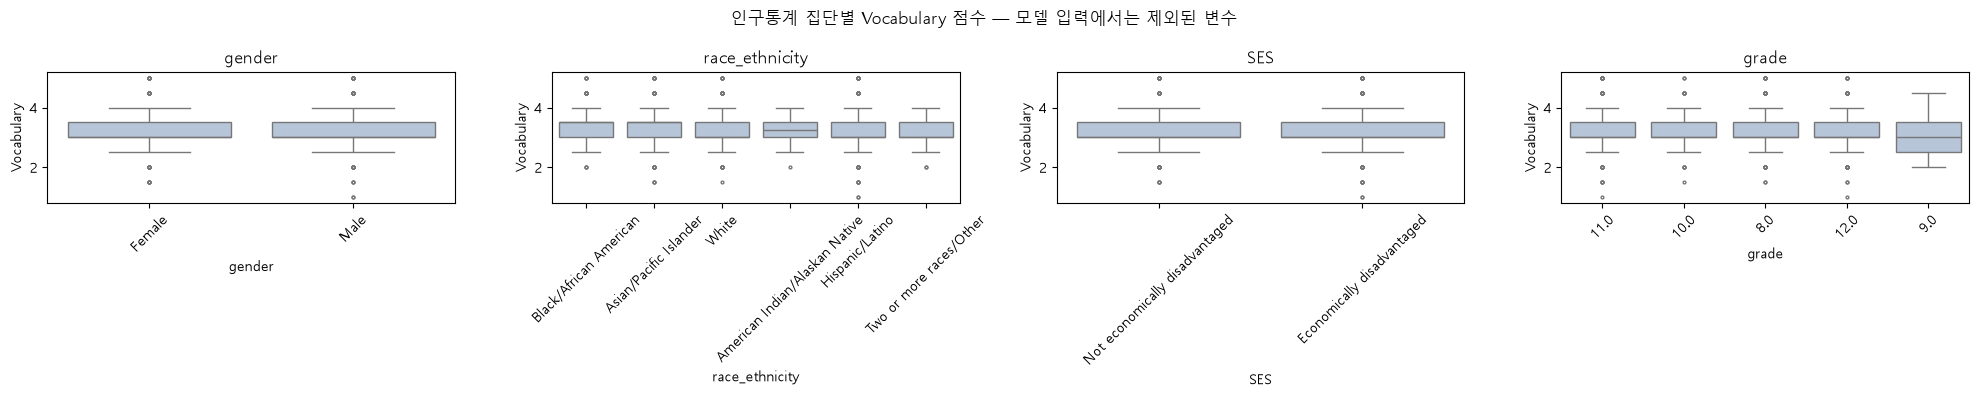

In [17]:
# ── [6-2] 집단별 점수 분포 ────────────────────────────────
#
# 확인할 것은 두 가지입니다.
#   ① 집단 간 평균 점수 차이가 존재하는가
#   ② 그 차이가 표본 크기를 고려해도 의미 있는 수준인가
#
# 차이가 있다는 사실 자체는 데이터의 특성이지 모델의 결함이 아닙니다.
# 중요한 것은 이 차이를 모델이 학습하지 않도록 설계했다는 점입니다.

if demo_ok:
    for c in [c for c in DEMO_COLS if c in eda.columns]:
        g = eda.groupby(c)[TARGET].agg(['count', 'mean', 'std']).round(3)
        g = g.sort_values('mean', ascending=False)
        spread = g['mean'].max() - g['mean'].min()
        print(f'\n{"=" * 60}')
        print(f'{c}  — 집단 간 평균 최대 격차: {spread:.3f}점')
        print('=' * 60)
        print(g.to_string())

    demo_avail = [c for c in DEMO_COLS if c in eda.columns]
    fig, axes = plt.subplots(1, len(demo_avail), figsize=(5 * len(demo_avail), 4))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, demo_avail):
        order = eda.groupby(c)[TARGET].mean().sort_values(ascending=False).index
        sns.boxplot(x=eda[c], y=eda[TARGET], ax=ax, order=order,
                    color='lightsteelblue', fliersize=2)
        ax.set_title(c)
        ax.tick_params(axis='x', rotation=45)
    fig.suptitle('인구통계 집단별 Vocabulary 점수 — 모델 입력에서는 제외된 변수', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('인구통계 변수 결합에 실패해 이 분석을 건너뜁니다.')

In [18]:
# ── [6-3] 편향 우회 유입 점검 ─────────────────────────────
#
# 인구통계 변수를 제외해도, 그와 강하게 연관된 텍스트 특성이 남아 있으면
# 모델은 간접적으로 같은 편향을 학습할 수 있습니다.
# 이를 대리 차별(proxy discrimination)이라고 합니다.
#
# 확인 방법: 각 인구통계 변수를 예측 피처들로 얼마나 설명할 수 있는지 봅니다.
# 잘 설명된다면(= 집단 간 피처 값이 크게 다르다면) 우회 경로가 존재합니다.

if demo_ok:
    check_feats = [c for c in derived if c in eda.columns]
    print('인구통계 변수 ↔ 예측 피처의 연관성')
    print('(집단 간 피처 평균 차이를 표준편차로 나눈 값 = 효과크기)\n')

    for c in [c for c in DEMO_COLS if c in eda.columns]:
        gm = eda.groupby(c)[check_feats].mean()
        # 집단 간 최대 격차를 전체 표준편차로 표준화
        eff = ((gm.max() - gm.min()) / eda[check_feats].std()).sort_values(ascending=False)
        top = eff.head(3)
        print(f'{c}:')
        for name, v in top.items():
            level = '큼' if v > 0.8 else ('중간' if v > 0.5 else '작음')
            print(f'    {name:24s} {v:.3f}  ({level})')
        print()

    print('효과크기 0.8 이상인 피처가 있다면, 그 피처를 통해')
    print('인구통계 정보가 간접적으로 모델에 전달될 수 있습니다.')
    print('제거할지 여부는 그 피처의 예측 기여도와 함께 판단해야 합니다.')
else:
    print('인구통계 변수 결합에 실패해 이 분석을 건너뜁니다.')

인구통계 변수 ↔ 예측 피처의 연관성
(집단 간 피처 평균 차이를 표준편차로 나눈 값 = 효과크기)

gender:
    len_z_in_prompt          0.282  (작음)
    ttr_ratio                0.202  (작음)
    mean_sent_length         0.156  (작음)

race_ethnicity:
    hapax_ratio              0.814  (큼)
    content_ttr              0.673  (중간)
    herdan_c                 0.650  (중간)

SES:
    mean_syllables           0.135  (작음)
    long_word_ratio          0.121  (작음)
    mean_word_length         0.108  (작음)

grade:
    prompt_freq              1.399  (큼)
    sent_length_std          0.866  (큼)
    sent_length_max          0.861  (큼)

효과크기 0.8 이상인 피처가 있다면, 그 피처를 통해
인구통계 정보가 간접적으로 모델에 전달될 수 있습니다.
제거할지 여부는 그 피처의 예측 기여도와 함께 판단해야 합니다.


---

# EDA 7. prompt 편중 점검

## 목적
과제 주제(prompt)에 따른 점수 차이와 표본 불균형을 확인합니다.

## 확인할 것

이 데이터의 prompt는 44종이며 편수가 극심하게 불균등합니다.
여기서 두 가지 위험이 발생합니다.

1. **표본이 적은 prompt의 통계는 불안정합니다.**
   19편짜리 그룹의 평균은 우연에 크게 좌우됩니다.

2. **prompt를 원핫 인코딩하면 희소 범주가 과적합을 유발합니다.**
   특정 prompt에만 존재하는 소수 사례를 모델이 암기할 수 있습니다.

STEP 4에서 30편 미만을 `OTHER`로 통합한 `prompt_grouped`를 만들어 둔 것이
이 문제에 대한 대응입니다. 그 처리가 타당했는지 여기서 확인합니다.

prompt 종수 (train): 44종
편수 범위: 9 ~ 236편

상위 10종
                                                count   mean    std
prompt                                                             
Distance learning                                 236  3.271  0.560
Success and failure                               183  3.090  0.510
Career commitment                                 171  3.155  0.532
Being busy                                        159  3.217  0.602
Impact of technology                              146  3.342  0.601
Positive attitudes                                140  3.221  0.567
Trying something beyond what you have mastered    140  3.132  0.525
First impressions                                 133  3.090  0.630
Three-year high school program                    126  3.313  0.632
Individuality                                     117  3.115  0.603

하위 10종
                                        count   mean    std
prompt                                                     
Cell phon

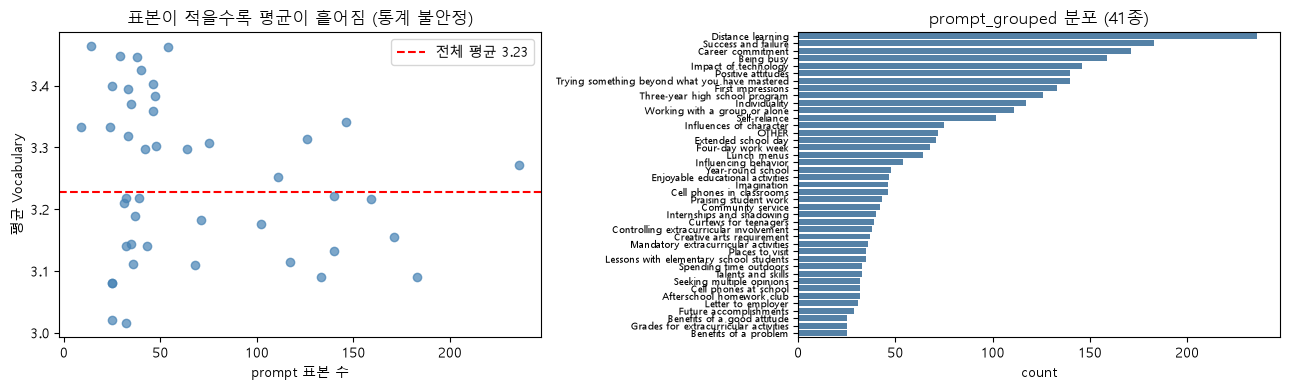

In [19]:
# ── [7-1] prompt별 표본 수와 점수 분포 ───────────────────

pg = (eda.groupby('prompt')[TARGET]
      .agg(['count', 'mean', 'std'])
      .sort_values('count', ascending=False)
      .round(3))

print(f'prompt 종수 (train): {eda["prompt"].nunique()}종')
print(f'편수 범위: {pg["count"].min()} ~ {pg["count"].max()}편')
print(f'\n상위 10종')
print(pg.head(10).to_string())
print(f'\n하위 10종')
print(pg.tail(10).to_string())

print(f'\nprompt별 평균 점수 격차: '
      f'{pg["mean"].max() - pg["mean"].min():.3f}점')
print('  → 격차가 크면 주제가 점수에 영향을 준다는 뜻이며,')
print('     STEP 4의 과제 상대화(F군) 변수가 필요한 근거가 됩니다.')

# 표본 수와 평균의 관계 — 표본이 적을수록 평균이 흩어지는지 확인
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(pg['count'], pg['mean'], alpha=.7, color='steelblue')
axes[0].axhline(eda[TARGET].mean(), color='red', ls='--',
                label=f'전체 평균 {eda[TARGET].mean():.2f}')
axes[0].set_xlabel('prompt 표본 수')
axes[0].set_ylabel('평균 Vocabulary')
axes[0].set_title('표본이 적을수록 평균이 흩어짐 (통계 불안정)')
axes[0].legend()

sns.countplot(y=eda['prompt_grouped'], ax=axes[1],
              order=eda['prompt_grouped'].value_counts().index,
              color='steelblue')
axes[1].set_title(f'prompt_grouped 분포 ({eda["prompt_grouped"].nunique()}종)')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

---

# 정리 — 확인 사항에 대한 답변

`프로젝트_진행_단계.md`의 EDA 확인 사항 5문항에 대한 답을 정리합니다.
아래 셀은 앞의 분석 결과를 종합해 자동으로 출력합니다.

In [20]:
# ── [Z-1] 확인 사항 종합 답변 ─────────────────────────────

print('=' * 78)
print('EDA 확인 사항 종합')
print('=' * 78)

# ① 어떤 Feature가 Target과 관계가 높은가
print('\n① 어떤 Feature가 Target과 관계가 높은가?')
top5 = corr_tbl.head(5)
for name, row in top5.iterrows():
    print(f"   {name:24s} r={row['r(Target)']:+.3f}  "
          f"(길이교란 {row['r(Token)']:+.3f}, {row['변수군']})")

# ② Feature간 상관관계가 높은 변수는 없는가
print('\n② Feature간 상관관계가 높은 변수는 없는가?')
print(f'   상관 0.85 초과 쌍: {len(pairs)}쌍')
print(f'   VIF 10 이상: {(vif_tbl["VIF"] >= 10).sum()}개 '
      f'(그중 완전 종속 {(vif_tbl["VIF"] == np.inf).sum()}개)')

# ③ 이상치가 존재하는가
print('\n③ 이상치가 존재하는가?')
print(f'   길이 IQR 이탈: {int(eda["flag_len_outlier"].sum())}건 '
      f'({eda["flag_len_outlier"].mean() * 100:.2f}%)')
print(f'   MTLD 측정 무효(100토큰 미만): {int(eda["flag_very_short"].sum())}건')
print('   → STEP 2에서 제거하지 않고 플래그로 보존했습니다.')

# ④ 데이터 분포가 한쪽으로 치우쳐 있는가
print('\n④ 데이터 분포가 한쪽으로 치우쳐 있는가?')
print(f'   Target 왜도: {eda[TARGET].skew():+.3f}  '
      f'(상위 3구간이 전체의 {eda[TARGET].value_counts().nlargest(3).sum() / len(eda) * 100:.1f}%)')
print(f'   왜도 1.0 초과 Feature: {len(heavy)}개')

# ⑤ 회귀모델 학습에 적합하지 않은 Feature는 없는가
print('\n⑤ 회귀모델 학습에 적합하지 않은 Feature는 없는가?')
weak = corr_tbl[corr_tbl['r(Target)'].abs() < 0.05].index.tolist()
inf_vif = vif_tbl[vif_tbl['VIF'] == np.inf].index.tolist()
print(f'   |r| < 0.05 (예측력 없음): {weak}')
print(f'   완전 종속 (반드시 제거): {inf_vif}')
print('   → 단, flag_very_short는 예측이 아니라 MTLD 대치 표시가 목적이므로 유지합니다.')

print('\n' + '=' * 78)

EDA 확인 사항 종합

① 어떤 Feature가 Target과 관계가 높은가?
   Type                     r=+0.388  (길이교란 +0.849, H. 원본)
   guiraud                  r=+0.380  (길이교란 +0.364, A. 다양성)
   MTLD_valid               r=+0.346  (길이교란 +0.094, A. 다양성)
   MTLD                     r=+0.346  (길이교란 +0.071, H. 원본)
   num_sent                 r=+0.341  (길이교란 +0.623, H. 원본)

② Feature간 상관관계가 높은 변수는 없는가?
   상관 0.85 초과 쌍: 8쌍
   VIF 10 이상: 11개 (그중 완전 종속 5개)

③ 이상치가 존재하는가?
   길이 IQR 이탈: 86건 (2.87%)
   MTLD 측정 무효(100토큰 미만): 18건
   → STEP 2에서 제거하지 않고 플래그로 보존했습니다.

④ 데이터 분포가 한쪽으로 치우쳐 있는가?
   Target 왜도: +0.204  (상위 3구간이 전체의 78.9%)
   왜도 1.0 초과 Feature: 21개

⑤ 회귀모델 학습에 적합하지 않은 Feature는 없는가?
   |r| < 0.05 (예측력 없음): ['beyond_2k_ratio', 'soph_z_in_prompt', 'flag_very_short', 'prompt_freq', 'repeat_bigram_ratio', 'n_pii', 'num_para', 'ttr_ratio', 'TTR']
   완전 종속 (반드시 제거): ['k2_ratio', 'beyond_2k_ratio', 'k1_ratio', 'lexical_density', 'function_word_ratio']
   → 단, flag_very_short는 예측이 아니라 MTLD 대치 표시가 목적이므로 유지합니다.



In [21]:
# ── [Z-2] 종합 리포트 저장 ────────────────────────────────
#
# 변수별 통계·상관·VIF를 하나의 표로 합쳐 저장합니다.
# STEP 6의 변수 선택은 이 파일을 근거로 진행합니다.

report = corr_tbl.copy()
report['왜도'] = [round(eda[c].skew(), 3) for c in report.index]
report['std'] = [round(eda[c].std(), 4) for c in report.index]
report['VIF'] = [round(vif_tbl.loc[c, 'VIF'], 2) if c in vif_tbl.index else np.nan
                 for c in report.index]

report.to_csv('data/eda_feature_report.csv', encoding='utf-8-sig')
print('저장 완료: data/eda_feature_report.csv')
print(f'  {report.shape[0]}개 변수 × {report.shape[1]}개 지표')
print('\n상위 15개')
print(report.head(15).to_string())

저장 완료: data/eda_feature_report.csv
  37개 변수 × 8개 지표

상위 15개
                     변수군  r(Target)  ρ(Target)     차이  r(Token)     왜도       std    VIF
변수                                                                                     
Type               H. 원본      0.388      0.393  0.005     0.849  0.717   48.9299    NaN
guiraud           A. 다양성      0.380      0.368 -0.013     0.364  0.217    1.2606  19.37
MTLD_valid        A. 다양성      0.346      0.347  0.000     0.094  0.644   11.0883   2.90
MTLD               H. 원본      0.346      0.344 -0.001     0.071  0.702   10.9448    NaN
num_sent           H. 원본      0.341      0.370  0.030     0.623  1.078   10.0950    NaN
oov_ratio         D. 정확성     -0.315     -0.282 -0.033    -0.113  3.671    0.0207   1.71
len_z_in_prompt   F. 상대화      0.270      0.303  0.033     0.947  1.133    0.9753   5.92
Token              H. 원본      0.266      0.296  0.030     1.000  1.099  188.9192    NaN
num_words3         H. 원본      0.265      0.295  0.030     0.

---

## 다음 단계

| 단계 | 작업 | 근거 파일 |
|---|---|---|
| **STEP 6** | Feature Selection — 고상관·고VIF 변수 제거, `clean_beyond_2k` 생성 | `eda_feature_report.csv` |
| **STEP 7** | 인코딩(`prompt_grouped` 원핫) + 스케일링 | — |

### STEP 7에서 반드시 지킬 것

스케일러와 인코더는 **train에만 `fit`** 하고, test에는 `transform`만 적용합니다.
전체 데이터에 `fit`하면 test의 평균·표준편차가 변환 기준에 반영되어 누수가 발생합니다.

```python
scaler.fit(X_train)                     # train으로만 학습
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)    # test는 변환만
```

### 트리 계열 모델에는 스케일링이 불필요합니다

Random Forest는 분기 기준을 값의 순서로 정하므로 스케일에 영향받지 않습니다.
선형회귀·Ridge·Lasso는 정규화 항이 계수 크기에 비례하므로 스케일링이 필수입니다.
두 계열을 비교할 예정이므로 **스케일링 전후 데이터를 모두 보관**하는 편이 편리합니다.